## Introducción al Clustering
El objetivo de este notebook es encontrar grupos naturales (clusters) de viviendas que compartan características similares. No tenemos etiquetas predefinidas (aprendizaje no supervisado), por lo que probaremos varios algoritmos y usaremos métricas estadísticas para decidir el mejor número de grupos.

In [1]:
import pandas as pd
import numpy as np

from sklearn.cluster import KMeans
from sklearn.mixture import GaussianMixture
from sklearn.metrics import silhouette_score, davies_bouldin_score, calinski_harabasz_score

import matplotlib.pyplot as plt
import seaborn as sns

import warnings
warnings.filterwarnings("ignore")

In [8]:
df = pd.read_csv("df_50k_reducido.csv")
print(df.shape)
df.head()


(50000, 6)


,pca_1,pca_2,urbanizacion,umap_1,umap_2,urbanizacion.1
0,1.341647,-0.638687,3,-2.483555,21.471657,3
1,-0.240391,-0.120306,3,21.675484,-15.174466,3
2,-0.496116,-0.997139,3,4.874802,-3.024218,3
3,1.185772,0.128228,3,10.784920,11.096844,3
4,0.023866,0.379015,3,9.180115,11.333056,3


In [10]:
# Quitar la columna duplicada 'urbanizacion.1' si existe
cols_dup = [c for c in df.columns if "urbanizacion" in c]
print("columnas detectadas:", cols_dup)

# Nos quedamos con SOLO la primera
df = df.loc[:, ~df.columns.duplicated()]

# O explícito:
if "urbanizacion.1" in df.columns:
    df = df.drop(columns=["urbanizacion.1"])

print("Columnas finales:", df.columns)

columnas detectadas: ['urbanizacion', 'urbanizacion.1']
Columnas finales: Index(['pca_1', 'pca_2', 'urbanizacion', 'umap_1', 'umap_2'], dtype='object')


In [11]:
df.head()

,pca_1,pca_2,urbanizacion,umap_1,umap_2
0,1.341647,-0.638687,3,-2.483555,21.471657
1,-0.240391,-0.120306,3,21.675484,-15.174466
2,-0.496116,-0.997139,3,4.874802,-3.024218
3,1.185772,0.128228,3,10.784920,11.096844
4,0.023866,0.379015,3,9.180115,11.333056


In [13]:
X = df[["pca_1","pca_2","umap_1","umap_2"]]
y_urb = df["urbanizacion"]


In [14]:
def evaluar_modelo(nombre, labels, X):
    sil = silhouette_score(X, labels)
    db = davies_bouldin_score(X, labels)
    ch = calinski_harabasz_score(X, labels)

    print(f"\n### {nombre} ###")
    print(f"Silhouette:          {sil:.4f}")
    print(f"Davies-Bouldin:      {db:.4f}")
    print(f"Calinski-Harabasz:   {ch:.2f}")

    return sil, db, ch


## 1. KMeans: Búsqueda del K óptimo
Ejecutamos KMeans iterando desde k=3 hasta k=10. Evaluamos cada k con tres métricas clave:
1.  **Silhouette Score:** Mide qué tan similar es un objeto a su propio cluster comparado con otros. (Cercano a 1 es mejor).
2.  **Davies-Bouldin:** Mide la similitud media entre clusters. (Menor es mejor, indica mejor separación).
3.  **Calinski-Harabasz:** Relación entre la dispersión dentro del cluster y la separación entre clusters. (Mayor es mejor).

In [15]:
resultados_kmeans = []

for k in range(3, 11):
    km = KMeans(n_clusters=k, random_state=42)
    labels = km.fit_predict(X)

    sil, db, ch = evaluar_modelo(f"KMeans (k={k})", labels, X)
    resultados_kmeans.append([k, sil, db, ch])



### KMeans (k=3) ###
Silhouette:          0.5323
Davies-Bouldin:      0.7316
Calinski-Harabasz:   77985.17

### KMeans (k=4) ###
Silhouette:          0.5443
Davies-Bouldin:      0.7599
Calinski-Harabasz:   73431.13

### KMeans (k=5) ###
Silhouette:          0.5567
Davies-Bouldin:      0.8194
Calinski-Harabasz:   72028.65

### KMeans (k=6) ###
Silhouette:          0.5975
Davies-Bouldin:      0.6435
Calinski-Harabasz:   75358.55

### KMeans (k=7) ###
Silhouette:          0.6343
Davies-Bouldin:      0.4864
Calinski-Harabasz:   85369.25

### KMeans (k=8) ###
Silhouette:          0.6774
Davies-Bouldin:      0.5069
Calinski-Harabasz:   140173.02

### KMeans (k=9) ###
Silhouette:          0.6982
Davies-Bouldin:      0.4352
Calinski-Harabasz:   153327.85

### KMeans (k=10) ###
Silhouette:          0.7278
Davies-Bouldin:      0.3650
Calinski-Harabasz:   191257.49


## Análisis de Métricas (Método del Codo y Silueta)
Observamos los gráficos para tomar una decisión:
*   Buscamos el punto donde la ganancia en calidad (Silhouette sube / Davies baja) empieza a estancarse (el "codo").
*   *Decisión:* Seleccionamos el **K con mejor balance** (generalmente donde Silhouette es alto antes de caer drásticamente).

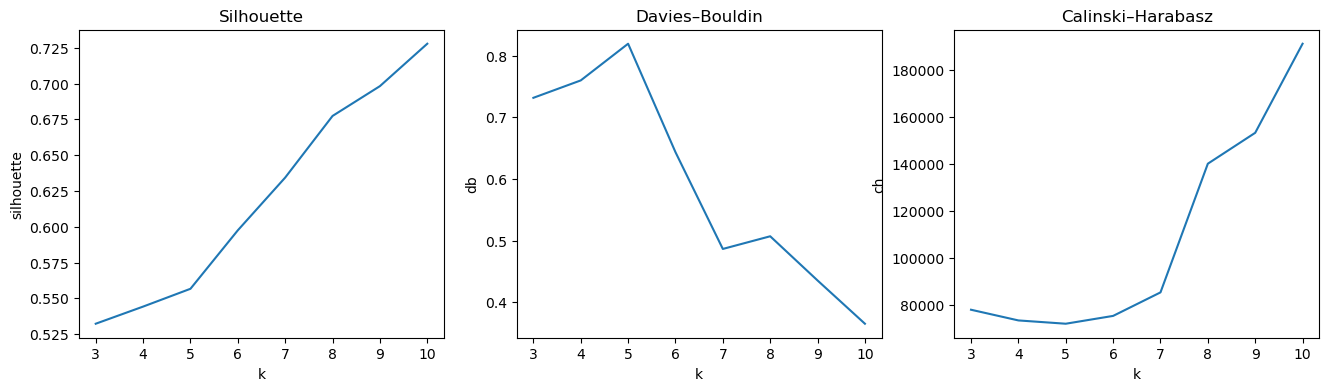

In [17]:
resultados_kmeans = pd.DataFrame(resultados_kmeans, columns=["k","silhouette","db","ch"])

fig, ax = plt.subplots(1,3, figsize=(16,4))

sns.lineplot(data=resultados_kmeans, x="k", y="silhouette", ax=ax[0])
ax[0].set_title("Silhouette")

sns.lineplot(data=resultados_kmeans, x="k", y="db", ax=ax[1])
ax[1].set_title("Davies–Bouldin")

sns.lineplot(data=resultados_kmeans, x="k", y="ch", ax=ax[2])
ax[2].set_title("Calinski–Harabasz")

plt.show()


In [18]:
# best_k = resultados_kmeans.sort_values("silhouette", ascending=False).iloc[0]["k"] <--- Este es para seleccionarlo automaticamente
best_k = 7
print("Mejor K encontrado:", best_k)

kmeans_final = KMeans(n_clusters=int(best_k), random_state=42)
df["cluster_kmeans"] = kmeans_final.fit_predict(X)


Mejor K encontrado: 7


## Visualización de Clusters en el Espacio UMAP
Proyectamos las etiquetas generadas por KMeans sobre las coordenadas UMAP calculadas en el notebook anterior.
*   Si los colores (clusters) se ven bien separados en el mapa 2D, significa que los grupos tienen sentido tanto en el espacio original (KMeans) como en la variedad topológica (UMAP).

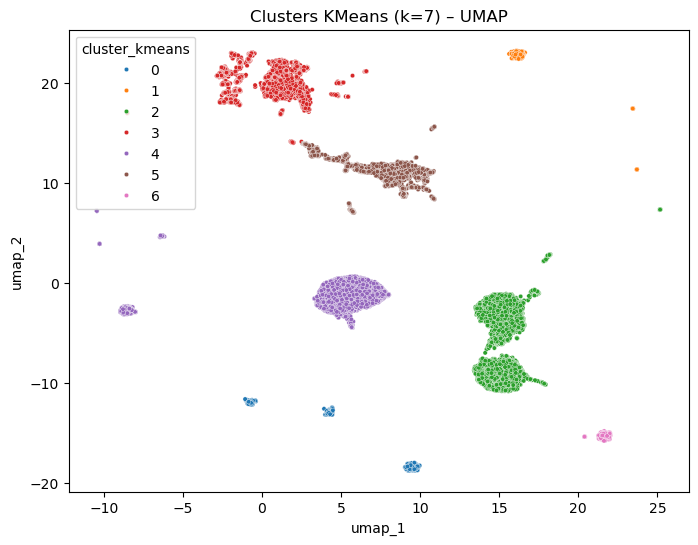

In [19]:
plt.figure(figsize=(8,6))
sns.scatterplot(data=df, x="umap_1", y="umap_2",
                hue="cluster_kmeans", palette="tab10", s=10)
plt.title(f"Clusters KMeans (k={best_k}) – UMAP")
plt.show()


## 2. Gaussian Mixture Models (GMM)
A diferencia de KMeans (que asume clusters esféricos), GMM asume que los datos provienen de distribuciones gaussianas y permite formas elípticas.
*   GMM es más flexible y nos sirve como **validación cruzada**. Si GMM encuentra una estructura similar a KMeans, tenemos mayor certeza de la estabilidad de los resultados.

In [20]:
resultados_gmm = []

for k in range(3, 11):
    gmm = GaussianMixture(n_components=k, covariance_type="full", random_state=42)
    labels = gmm.fit_predict(X)

    sil, db, ch = evaluar_modelo(f"GMM (k={k})", labels, X)
    resultados_gmm.append([k, sil, db, ch])



### GMM (k=3) ###
Silhouette:          0.4875
Davies-Bouldin:      0.7951
Calinski-Harabasz:   69139.64

### GMM (k=4) ###
Silhouette:          0.5128
Davies-Bouldin:      0.7768
Calinski-Harabasz:   67198.66

### GMM (k=5) ###
Silhouette:          0.5305
Davies-Bouldin:      0.8257
Calinski-Harabasz:   64782.57

### GMM (k=6) ###
Silhouette:          0.5762
Davies-Bouldin:      0.6630
Calinski-Harabasz:   66969.40

### GMM (k=7) ###
Silhouette:          0.6136
Davies-Bouldin:      0.5090
Calinski-Harabasz:   73693.31

### GMM (k=8) ###
Silhouette:          0.6562
Davies-Bouldin:      0.5307
Calinski-Harabasz:   102076.98

### GMM (k=9) ###
Silhouette:          0.6769
Davies-Bouldin:      0.4608
Calinski-Harabasz:   104902.46

### GMM (k=10) ###
Silhouette:          0.7096
Davies-Bouldin:      0.3861
Calinski-Harabasz:   113481.35


In [21]:
resultados_gmm = pd.DataFrame(resultados_gmm, columns=["k","silhouette","db","ch"])
best_k_gmm = resultados_gmm.sort_values("silhouette", ascending=False).iloc[0]["k"]

print("Mejor K para GMM:", best_k_gmm)

gmm_final = GaussianMixture(n_components=int(best_k_gmm), random_state=42)
df["cluster_gmm"] = gmm_final.fit_predict(X)


Mejor K para GMM: 10.0


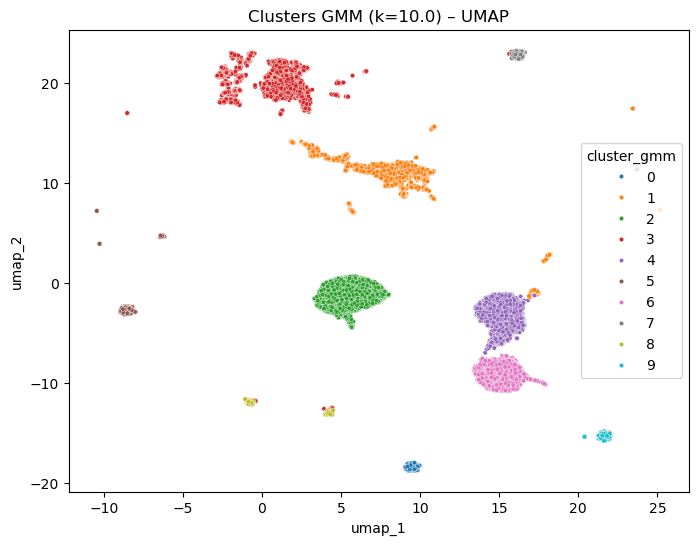

In [22]:
plt.figure(figsize=(8,6))
sns.scatterplot(data=df, x="umap_1", y="umap_2",
                hue="cluster_gmm", palette="tab10", s=10)
plt.title(f"Clusters GMM (k={best_k_gmm}) – UMAP")
plt.show()


## 3. Validación de Consistencia (Crosstab)
Cruzamos los resultados de KMeans vs. GMM.
*   **Interpretación:** Buscamos una diagonal fuerte o bloques definidos. Si el Cluster 1 de KMeans coincide mayoritariamente con el Cluster X de GMM, significa que ese grupo de viviendas es muy robusto y "real".

In [24]:
df_clusters = df[["cluster_kmeans","cluster_gmm","urbanizacion"]]
df_clusters.head()


,cluster_kmeans,cluster_gmm,urbanizacion
0,3,3,3
1,6,9,3
2,4,2,3
3,5,1,3
4,5,1,3


In [25]:
pd.crosstab(df["cluster_kmeans"], df["urbanizacion"])


urbanizacion,1,2,3
cluster_kmeans,,,
0,805,1204,1561
1,365,559,851
2,3021,4592,6205
3,1895,2773,4037
4,3002,4677,6485
5,1332,2046,2840
6,368,568,814


In [26]:
df.groupby("cluster_kmeans")["urbanizacion"].value_counts(normalize=True).mul(100).round(2)


cluster_kmeans  urbanizacion
0               3               43.73
                2               33.73
                1               22.55
1               3               47.94
                2               31.49
                1               20.56
2               3               44.91
                2               33.23
                1               21.86
3               3               46.38
                2               31.86
                1               21.77
4               3               45.79
                2               33.02
                1               21.19
5               3               45.67
                2               32.90
                1               21.42
6               3               46.51
                2               32.46
                1               21.03
Name: proportion, dtype: float64

In [27]:
df.groupby("cluster_gmm")["urbanizacion"].value_counts(normalize=True).mul(100).round(2)


cluster_gmm  urbanizacion
0            3               43.57
             2               33.05
             1               23.38
1            3               45.78
             2               32.82
             1               21.40
2            3               46.02
             2               33.02
             1               20.96
3            3               46.27
             2               31.99
             1               21.73
4            3               44.85
             2               33.19
             1               21.96
5            3               44.54
             2               32.89
             1               22.56
6            3               44.91
             2               33.25
             1               21.84
7            3               48.10
             2               31.21
             1               20.69
8            3               43.59
             2               34.59
             1               21.82
9            3               

## Exportación de Resultados
Guardamos el dataframe final incluyendo:
1.  Las coordenadas reducidas (`pca`, `umap`).
2.  Las etiquetas de los clusters (`cluster_kmeans`, `cluster_gmm`).
3.  La variable original de urbanización.

Este archivo será el input para el **Notebook 04**, donde perfilaremos y pondremos nombre a estos grupos.

In [28]:
df.to_csv("df_50k_clusters.csv", index=False)
print("Archivo exportado: df_50k_clusters.csv")


Archivo exportado: df_50k_clusters.csv
